In [1]:
import polars as pl
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import os
from collections import defaultdict
import datetime as dt
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
sys.path.insert(1, os.path.abspath(".."))
os.chdir(os.path.abspath('..')) # Change the workdir to the parent folder

# ── Visual defaults ───────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
SIRS_COLORS = {0: "#4CAF50", 1: "#FFC107", 2: "#FF9800", 3: "#F44336", 4: "#9C27B0"}

In [2]:
from src.configs.dataconfig import input_filenames_v3, input_output_config_3, input_filenames_v2, input_output_config_2
from src.dataloader import DataLoader

In [ ]:
print(input_filenames_v3)

ENCOUNTER_BASELINE_SCORES='Encounter Table with Baseline Values - June 2022 - May 2026 - 6.5.26.csv' FLOWSHEETS='flowsheets_bp - 6.8.26.csv' LABS='labs_with_fio2 - 6.9.26.csv' MEDS='Med Admin Events - 6.5.26.csv' PROCEDURES='Procedure Order Events - 6.5.26.csv' DIAGNOSIS='Diagnoses - 6.5.26.csv'


In [4]:
input_output_config_3.data_path

'/work/InternalMedicine/s223850/Sepsis-data/data/raw_data_phase3'

### Merge blood pressure with flowsheets

In [ ]:
file_path = Path(input_output_config_3.data_path)/Path("Blood Pressure - 6.8.26.csv")
flow_sheets = Path(input_output_config_3.data_path)/Path("Flowsheet Events - 6.5.26.csv")

fio2_path = Path(input_output_config_3.data_path)/Path("FIO2 - 6.9.26.csv")
labs_path = Path(input_output_config_3.data_path)/Path("Lab Results - 6.5.26.csv")

df_bp = pl.read_csv(file_path, infer_schema=False, null_values=['Null', "NULL", 'null'])
df_flowsheets = pl.read_csv(flow_sheets, infer_schema=False, null_values=['Null', "NULL", 'null'])

df_fio2 = pl.read_csv(fio2_path, infer_schema=False, null_values=['Null', "NULL", 'null'])
df_labs = pl.read_csv(labs_path, infer_schema=False, null_values=['Null', "NULL", 'null'])

# pl.concat([df_bp, df_flowsheets], how="vertical").write_csv(Path(input_output_config_3.data_path)/Path("flowsheets_bp - 6.8.26.csv"))
# pl.concat([df_fio2, df_labs], how='vertical').write_csv(Path(input_output_config_3.data_path)/Path("labs_with_fio2 - 6.9.26.csv"))

In [15]:
len(set(df_fio2['EncounterEpicCsn'])-set(df_labs['EncounterEpicCsn']))

6

In [48]:
len(set(df_bp['EncounterEpicCsn']).intersection(set(df_flowsheets['EncounterEpicCsn'])))

14904

In [49]:
len(set(df_flowsheets['EncounterEpicCsn'])-set(df_bp['EncounterEpicCsn']))

10

In [50]:
len(set(df_bp['EncounterEpicCsn'])-set(df_flowsheets['EncounterEpicCsn']))

15

In [18]:
os.path.dirname(input_output_config_3.output_path)

'/work/InternalMedicine/s223850/Sepsis-data/data/output'

### Combine df_sepsis v2, v3

In [3]:
# v3 
df_sepsis_3_v3 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),'phase3_v3','df_sepsis3.parquet'
	)
)
df_sepsis_2_v3 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),'phase3_v3','df_sepsis2.parquet'
	)
)
df_sepsis_1_v3 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),'phase3_v3','df_sepsis1.parquet'
	)
)

In [4]:
# v2 
df_sepsis_3_v2 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),'raw_data_phase3_v2_old','df_sepsis3.parquet'
	)
)
df_sepsis_2_v2 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),'raw_data_phase3_v2_old','df_sepsis2.parquet'
	)
)
df_sepsis_1_v2 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),'raw_data_phase3_v2_old','df_sepsis1.parquet'
	)
)

In [5]:
cols1 = df_sepsis_1_v3.columns
cols2 = df_sepsis_1_v3.columns
cols3 = df_sepsis_1_v3.columns
idx = cols2.index('earliest_sepsis1_instance')
cols2[idx] = 'earliest_sepsis2_instance'
cols3[idx] = 'earliest_sepsis3_instance'
cols2.remove('sirs_score')
cols3.remove('sirs_score')
cols1.remove('sirs_score')


In [6]:
df_sepsis_1_v3 = df_sepsis_1_v3.select(
    cols1
).with_columns(
    pl.lit(1).alias('sepsis_score')
).rename({"earliest_sepsis1_instance": "sepsis_instance"})

df_sepsis_2_v3 = df_sepsis_2_v3.select(
    cols2
).with_columns(
    pl.lit(2).alias('sepsis_score')
).rename({"earliest_sepsis2_instance": "sepsis_instance"})

df_sepsis_3_v3 = df_sepsis_3_v3.select(
    cols3
).with_columns(
    pl.lit(3).alias('sepsis_score')
).rename({"earliest_sepsis3_instance": "sepsis_instance"})

df_sepsis_v3 = pl.concat([df_sepsis_1_v3, df_sepsis_2_v3, df_sepsis_3_v3], how='vertical')

In [7]:
df_sepsis_1_v2 = df_sepsis_1_v2.select(
    cols1
).with_columns(
    pl.lit(1).alias('sepsis_score')
).rename({"earliest_sepsis1_instance": "sepsis_instance"})

df_sepsis_2_v2 = df_sepsis_2_v2.select(
    cols2
).with_columns(
    pl.lit(2).alias('sepsis_score')
).rename({"earliest_sepsis2_instance": "sepsis_instance"})

df_sepsis_3_v2 = df_sepsis_3_v2.select(
    cols3
).with_columns(
    pl.lit(3).alias('sepsis_score')
).rename({"earliest_sepsis3_instance": "sepsis_instance"})

df_sepsis_v2 = pl.concat([df_sepsis_1_v2, df_sepsis_2_v2, df_sepsis_3_v2], how='vertical')

In [79]:
df_sepsis_v3.group_by("EncounterEpicCsn").agg(
    pl.col("sepsis_score").max().alias('max_sepsis_score')
)['max_sepsis_score'].value_counts(sort=True)

max_sepsis_score,count
i32,u64
2,7173
1,3621
3,3084


In [80]:
df_sepsis_v2.group_by("EncounterEpicCsn").agg(
    pl.col("sepsis_score").max().alias('max_sepsis_score')
)['max_sepsis_score'].value_counts(sort=True)

max_sepsis_score,count
i32,u64
2,8284
1,4041
3,2252


In [91]:
df_sepsis_v2_max_per_encounter = df_sepsis_v2.group_by("EncounterEpicCsn").agg(
	pl.col("sepsis_score").max().alias('max_sepsis_score')	
)

df_sepsis_v2_max_instants = df_sepsis_v2.join(
	df_sepsis_v2_max_per_encounter,
	on=["EncounterEpicCsn"],
	how="inner"
).filter(
    pl.col("sepsis_score") == pl.col("max_sepsis_score")
).group_by(
	"EncounterEpicCsn"
).agg(
	pl.col("sepsis_instance").min().alias("sepsis_instant"),
    pl.col("sepsis_score").max().alias('sepsis_score_max'),
    pl.col("sepsis_score").min().alias('sepsis_score_min'),
    pl.col("max_sepsis_score").min().alias('max_sepsis_score_min'),
    pl.col("max_sepsis_score").max().alias('max_sepsis_score_max'),
)


df_sepsis_v3_max_per_encounter = df_sepsis_v3.group_by("EncounterEpicCsn").agg(
	pl.col("sepsis_score").max().alias('max_sepsis_score')	
)

df_sepsis_v3_max_instants = df_sepsis_v3.join(
	df_sepsis_v3_max_per_encounter,
	on=["EncounterEpicCsn"],
	how="inner"
).filter(
    pl.col("sepsis_score") == pl.col("max_sepsis_score")
).group_by(
	"EncounterEpicCsn"
).agg(
	pl.col("sepsis_instance").min().alias("sepsis_instant"),
    pl.col("sepsis_score").max().alias('sepsis_score_max'),
    pl.col("sepsis_score").min().alias('sepsis_score_min'),
    pl.col("max_sepsis_score").min().alias('max_sepsis_score_min'),
    pl.col("max_sepsis_score").max().alias('max_sepsis_score_max'),
)

In [ ]:
df_sepsis_v2.join(
    df_sepsis_v2.group_by(
		"EncounterEpicCsn"
	).agg(
		pl.col("sepsis_instance").min().alias("first_sepsis_instance")
	),
	on=["EncounterEpicCsn"],
	how="inner"
).filter(pl.col("sepsis_instance")==pl.col("first_sepsis_instance")).group_by(
    "EncounterEpicCsn"
).agg(
    pl.col("sepsis_score").max(),
    pl.col("sepsis_instance").max().alias('sepsis_instance_max'),
    pl.col("sepsis_instance").min().alias('sepsis_instance_min'),
    pl.col("first_sepsis_instance").min().alias('first_sepsis_instance_min'),
    pl.col("first_sepsis_instance").max().alias('first_sepsis_instance_max'),

)

EncounterEpicCsn,sepsis_score,sepsis_instance_max,sepsis_instance_min,first_sepsis_instance_min,first_sepsis_instance_max
i64,i32,datetime[μs],datetime[μs],datetime[μs],datetime[μs]
667079614,2,2022-08-20 15:18:00,2022-08-20 15:18:00,2022-08-20 15:18:00,2022-08-20 15:18:00
716799274,1,2024-11-30 19:54:00,2024-11-30 19:54:00,2024-11-30 19:54:00,2024-11-30 19:54:00
704363461,1,2024-05-22 01:25:00,2024-05-22 01:25:00,2024-05-22 01:25:00,2024-05-22 01:25:00
680474280,1,2023-04-16 11:46:00,2023-04-16 11:46:00,2023-04-16 11:46:00,2023-04-16 11:46:00
701797308,1,2024-04-10 11:14:00,2024-04-10 11:14:00,2024-04-10 11:14:00,2024-04-10 11:14:00
…,…,…,…,…,…
733358069,1,2025-08-13 18:17:00,2025-08-13 18:17:00,2025-08-13 18:17:00,2025-08-13 18:17:00
725043544,1,2025-04-09 23:51:00,2025-04-09 23:51:00,2025-04-09 23:51:00,2025-04-09 23:51:00
687348891,1,2023-08-20 20:54:00,2023-08-20 20:54:00,2023-08-20 20:54:00,2023-08-20 20:54:00


### Differences between v2 and v3 of the raw dataset

In [8]:
df_all_v2 = DataLoader(input_output_config_2).load_data()

In [9]:
df_all_v3 = DataLoader(input_output_config_3).load_data()

In [10]:
df_enc = df_all_v3.select(
    "EncounterEpicCsn",
	'Ethnicity',
	'PrincipalProblem',
	'PatientAgeAtAdmission',
	'Sex',
	'AdmissionType',
	'AdmissionSource',
	'AdmissionOrigin',
	"Death_Flag",
    "Sepsis_Category",
	'Cancer_Registry_YN',
	'HIV_Registry_YN',
	'Immunocrompromised_Registry_YN',
	'CKD_Dialysis_Registry_YN',
	'Solid_Organ_Transplant_Registry_YN',
	'Pregnancy_Registry_YN'
).group_by("EncounterEpicCsn").agg(
    pl.col("Ethnicity").first(),
	pl.col("AdmissionType").first(),
	pl.col("AdmissionSource").first(),
	pl.col("AdmissionOrigin").first(),
	pl.col("Death_Flag").first(),
	pl.col("Sepsis_Category").first(),
	pl.col("PrincipalProblem").first(),
	pl.col("PatientAgeAtAdmission").first(),
    pl.col("Cancer_Registry_YN").first(),
	pl.col('HIV_Registry_YN').first(),
	pl.col('Immunocrompromised_Registry_YN').first(),
	pl.col('CKD_Dialysis_Registry_YN').first(),
	pl.col('Solid_Organ_Transplant_Registry_YN').first(),
	pl.col('Pregnancy_Registry_YN').first()
)

In [12]:
df_enc

EncounterEpicCsn,Ethnicity,AdmissionType,AdmissionSource,AdmissionOrigin,Death_Flag,Sepsis_Category,PrincipalProblem,PatientAgeAtAdmission,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN
i64,str,str,str,str,i64,str,str,f64,str,str,str,str,str,str
729317406,"""Non-Hispanic/Latino""","""Emergency""","""Home & Outside Location""","""ED Admission""",0,"""POA-1""","""Pneumonia of both lungs due to…",58.346338,"""0""","""0""","""0""","""1""","""0""","""0"""
676014811,"""Non-Hispanic/Latino""","""Emergency""","""Home & Outside Location""","""ED Admission""",0,"""NPOA-1""","""Malignant pleural effusion""",45.289527,"""1""","""0""","""0""","""0""","""0""","""0"""
727200338,"""Non-Hispanic/Latino""","""Emergency""","""Home & Outside Location""","""ED Admission""",0,"""POA-1""","""Empyema (*)""",75.997262,"""0""","""0""","""0""","""0""","""0""","""0"""
663338070,"""Hispanic or Latino""","""Emergency""","""Home & Outside Location""","""ED Admission""",0,"""POA-3""","""Septic shock""",73.256673,"""1""","""0""","""0""","""0""","""0""","""0"""
667353438,"""Non-Hispanic/Latino""","""Emergency""","""Home & Outside Location""","""ED Admission""",0,"""POA-2""","""Abdominal visceral abscess (*)""",65.869952,"""0""","""0""","""0""","""0""","""0""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
668870684,"""Non-Hispanic/Latino""","""Emergency""","""Short Term General Hospital""","""ED Admission""",0,"""POA-1""","""Abdominal visceral abscess (*)""",77.075975,"""1""","""0""","""0""","""0""","""0""","""0"""
720206165,"""Non-Hispanic/Latino""","""Emergency""","""Home & Outside Location""","""ED Admission""",0,"""POA-1""","""Hypernatremia""",73.500342,"""0""","""0""","""0""","""0""","""0""","""0"""
680114978,"""Non-Hispanic/Latino""","""Emergency""","""Home & Outside Location""","""ED Admission""",0,"""POA-2""","""Prostate abscess""",65.993155,"""1""","""0""","""0""","""0""","""0""","""0"""


In [15]:
df_all_v2.shape, df_all_v3.shape

((8814652, 46), (20767931, 52))

In [6]:
df_all_v3.shape[0]/df_all_v2.shape[0]

2.3560693037002483

In [13]:
df_all_v2['Event_DateTime'].min(), df_all_v2['Event_DateTime'].max(), (df_all_v2['Event_DateTime'].max() - df_all_v2['Event_DateTime'].min()).total_seconds()/(60*60*24)/365

(datetime.datetime(2024, 3, 6, 3, 9, 37, 20000),
 datetime.datetime(2026, 3, 19, 9, 20),
 2.036321124429224)

In [14]:
df_all_v3['Event_DateTime'].min(), df_all_v3['Event_DateTime'].max(), (df_all_v3['Event_DateTime'].max() - df_all_v3['Event_DateTime'].min()).total_seconds()/(60*60*24)/365

(datetime.datetime(2022, 5, 5, 2, 5, 3, 487000),
 datetime.datetime(2026, 6, 5, 2, 6, 26, 310000),
 4.087673859176814)

In [64]:
df_all_v3.columns

['EncounterEpicCsn',
 'Event_DateTime',
 'Type',
 'Event_Grouper',
 'Event_Name',
 'NumericValue',
 'Value',
 'Flag',
 'PrimaryMrn',
 'PatientAgeAtAdmission',
 'Sex',
 'Ethnicity',
 'FirstRace',
 'MultiRacial',
 'EncounterEpicCsn_right',
 'AdmissionDateValue',
 'DischargeDateValue',
 'Arrival_Instant',
 'FirstAdmissionOrderInstant',
 'InpatientAdmissionInstant',
 'Admitted_from_ED',
 'PatientClass',
 'InpatientAdmissionPatientClass',
 'HospitalService',
 'LengthOfStayInDays',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 'PrimaryCodedDiagnosis',
 'PrimaryCodedProcedureKey',
 'Death_Flag',
 'Original_POA_Condition',
 'Sepsis_Category',
 'Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'First_Suspected_Infection_Time',
 'Suspected_Infection_Criteria_Met',
 'Cancer_Registry_YN',
 'HIV_

In [16]:
set(df_all_v3.columns)-set(df_all_v2.columns), set(df_all_v2.columns)-set(df_all_v3.columns)

({'Ethnicity',
  'FirstAdmissionOrderInstant',
  'FirstRace',
  'MultiRacial',
  'PatientAgeAtAdmission',
  'Sex'},
 set())

In [21]:
set(df_all_v3['Type'])-set(df_all_v2['Type']), set(df_all_v2['Type'])-set(df_all_v3['Type'])

({'Blood Culture Results',
  'IV Antibiotics - First',
  'IV Antibiotics - Last',
  'IV Antibiotics - Single'},
 set())

In [51]:
df_all_v3.filter(pl.col("Type") == "Blood Culture Results")['Event_Grouper'].unique()

Event_Grouper
str
"""Blood Culture"""
"""Blood Culture - Confirmed Infe…"


In [53]:
df_all_v3.filter(pl.col("Event_Grouper") == "Blood Culture - Confirmed Infection")['Type'].unique()

Type
str
"""Blood Culture Results"""


In [7]:
set(df_all_v3['Event_Grouper'])-set(df_all_v2['Event_Grouper']), set(df_all_v2['Event_Grouper'])-set(df_all_v3['Event_Grouper'])

({'Bacteria in Urine',
  'Bacteria in Urine - Confirmed Infection',
  'Billing Diagnosis - Confirmed Infection',
  'Blood Culture',
  'Blood Culture - Confirmed Infection',
  'Encounter Diagnosis - Confirmed Infection',
  'Hospital Problem - Confirmed Infection',
  'Problem List - Confirmed Infection',
  'Sepsis Body Fluid Culture Orders - Confirmed Infection',
  'WBC in Urine',
  'WBC in Urine - Confirmed Infection'},
 {'AST',
  'Absolute Immature Granulocytes',
  'Absolute Lymphocytes',
  'Absolute Monocytes',
  'Absolute Neutrophil',
  'Admission',
  'Albumin',
  'Bld Gas Arterial POC ABL',
  'Blood Gas: pH',
  'Chloride',
  'EKG',
  'Gastrointestinal Assessment',
  'Genitourinary Assessment',
  'Imaging',
  'Immature Granulocytes Percent',
  'Lymphocytes Percent',
  'MCHC',
  'Monocytes Percent',
  'Neurological Assessment',
  'Neutrophil Percent',
  'Pain Scale',
  'Procalcitonin',
  'RBC',
  'RDW',
  'Respiratory Assessment',
  'Skin Assessment',
  'Sodium',
  'Urine Output',
  '

In [25]:
common_event_groupers = sorted(list(set(df_all_v3['Event_Name']).intersection(set(df_all_v2['Event_Name']))))

In [40]:
df_all_v3.filter(pl.col("Event_Grouper") == 'Blood Culture - Confirmed Infection')

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN
i64,datetime[μs],str,str,str,f64,str,str,i64,str,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str
741882497,2025-12-06 04:21:00,"""Blood Culture Results""","""Blood Culture - Confirmed Infe…","""CULTURE""",null,"""Aerobic Bottle Positive At 72-…","""1""",70538520,"""36.974674""","""Female""","""Non-Hispanic/Latino""","""Black or African American""","""0""",741882497,2025-12-04 00:00:00,2025-12-21 00:00:00,2025-12-04 19:17:00,2025-12-04 22:32:00,2025-12-04 22:59:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""17""","""UH 12G""","""UH 12G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis""","""Bloodstream infection due to c…","""Removal of TIVAD from Trunk Su…",0,"""POA-1""","""POA-1""",115.0,16.0,79.0,0.455,300.333333,null,null,null,"""2025-12-04 19:20:00.0000000""","""Suspected Infection Flowsheet""","""0""","""0""","""1""","""0""","""0""","""0"""
674136132,2022-12-20 08:34:00,"""Blood Culture Results""","""Blood Culture - Confirmed Infe…","""CULTURE""",null,"""Aerobic Bottle Positive At <24…","""1""",93265491,"""70.349075""","""Female""","""Non-Hispanic/Latino""","""Black or African American""","""0""",674136132,2022-12-18 00:00:00,2023-01-04 00:00:00,2022-12-18 20:41:00,2022-12-18 22:36:00,2022-12-19 00:44:00,"""Yes""","""Inpatient""","""Inpatient""","""Acute Care Emergency Surgery""","""17""","""UH 02O SICU""","""UH 07O""","""Emergency""","""Home & Outside Location""","""OR Admission""","""Septic shock""","""Sepsis due to anaerobes (*)""","""Excision of Buttock Subcu/Fasc…",0,"""POA-3""","""POA-3""",133.0,null,null,1.28,188.0,0.4,null,8.7,"""2022-12-18 21:01:00.0000000""","""IV Antibiotics + Blood Culture…","""0""","""0""","""0""","""0""","""0""","""0"""
706688153,2024-07-01 13:52:00,"""Blood Culture Results""","""Blood Culture - Confirmed Infe…","""CULTURE""",null,"""Aerobic Bottle Positive At <24…","""1""",70488243,"""55.679671""","""Female""","""Hispanic or Latino""","""White""","""0""",706688153,2024-07-01 00:00:00,2024-07-12 00:00:00,2024-07-01 12:01:00,2024-07-01 16:44:00,2024-07-01 17:18:00,"""Yes""","""Inpatient""","""Inpatient""","""Oncology - Solid Tumor""","""11""","""UH 06G""","""UH 11G ONC""","""Emergency""","""Physician Ofc/OP Clinic""","""ED Admission""","""Sepsis due to Pseudomonas aeru…","""Sepsis due to Pseudomonas (*)""","""Dilation of Com Bile Duct with…",0,"""POA-1""","""POA-1""",110.0,16.0,80.0,0.587222,278.882353,6.377778,106.222222,7.812353,"""2024-07-01 13:35:00.0000000""","""IV Antibiotics + Blood Culture…","""1""","""0""","""0""","""0""","""0""","""0"""
675610373,2023-01-19 06:28:00,"""Blood Culture Results""","""Blood Culture - Confirmed Infe…","""CULTURE""",null,"""Aerobic Bottle Positive At 24-…","""1""",94843335,"""68.331279""","""Male""","""Non-Hispanic/Latino""","""Black or African American""","""0""",675610373,2023-01-17 00:00:00,2023-01-27 00:00:00,2023-01-17 2

### Analysis of the Time difference between the start and the end of antibiotics

In [13]:
(
    df_all_v3.select(
		"EncounterEpicCsn",
		"Event_DateTime",
		"Type",
		"Event_Name",
	)
    .filter(
		pl.col("Type").is_in(["IV Antibiotics - First", "IV Antibiotics - Last"])
	)
    .sort(by=["EncounterEpicCsn", "Event_DateTime"])
	.with_columns(
        
	)
)

EncounterEpicCsn,Event_DateTime,Type,Event_Name
i64,datetime[μs],str,str
659308243,2022-06-15 15:59:14,"""IV Antibiotics - First""","""PIPERACILLIN-TAZOBACTAM (ZOSYN…"
659308243,2022-06-17 09:05:30,"""IV Antibiotics - Last""","""PIPERACILLIN-TAZOBACTAM (ZOSYN…"
659308243,2022-06-17 09:42:00,"""IV Antibiotics - First""","""CEFAZOLIN IV 1G IV PUSH"""
659308243,2022-06-18 04:24:49,"""IV Antibiotics - First""","""MICAFUNGIN 100MG IN NS 100ML (…"
659308243,2022-06-18 05:41:26,"""IV Antibiotics - First""","""PIPERACILLIN-TAZOBACTAM (ZOSYN…"
…,…,…,…
753579730,2026-05-26 10:19:04,"""IV Antibiotics - First""","""VANCOMYCIN IV 1500 MG (VIAL2BA…"
753579730,2026-05-27 03:17:00,"""IV Antibiotics - Last""","""VANCOMYCIN IV 1500 MG (VIAL2BA…"
753579730,2026-05-27 06:15:00,"""IV Antibiotics - Last""","""PIPERACILLIN-TAZOBACTAM 4.5G I…"


In [11]:
df_all_v3.filter(pl.col("Event_Grouper") == 'Antibiotics')['Event_Name'].n_unique()

332

In [111]:
df_all_v3.filter(
	pl.col("Event_Grouper") == 'Antibiotics'
).group_by(
    "EncounterEpicCsn", "Event_Name"
).agg(pl.len()).sort(by='EncounterEpicCsn')

EncounterEpicCsn,Event_Name,len
i64,str,u64
659308243,"""CEFAZOLIN IV 1G IV PUSH""",5
659308243,"""DAPTOMYCIN IV PUSH""",2
659308243,"""PIPERACILLIN-TAZOBACTAM (ZOSYN…",21
659308243,"""PIPERACILLIN-TAZOBACTAM (ZOSYN…",1
659308243,"""MICAFUNGIN 100MG IN NS 100ML (…",39
…,…,…
753579730,"""VANCOMYCIN IV 1500 MG (VIAL2BA…",3
753579730,"""AZITHROMYCIN 250 MG TAB""",1
753579730,"""PIPERACILLIN-TAZOBACTAM 4.5G I…",5


In [113]:
df_antibiotics_per_encounter = df_all_v3.filter(
	pl.col("Event_Grouper") == 'Antibiotics'
).group_by(
    "EncounterEpicCsn"
).agg(pl.col("Event_Name").n_unique()).sort(by='EncounterEpicCsn')

df_antibiotics_per_encounter.describe()

statistic,EncounterEpicCsn,Event_Name
str,f64,f64
"""count""",14804.0,14804.0
"""null_count""",0.0,0.0
"""mean""",7.0670e8,5.789989
"""std""",2.5857e7,3.371362
"""min""",6.59308243e8,1.0
"""25%""",6.84171039e8,4.0
"""50%""",7.05821824e8,5.0
"""75%""",7.28799005e8,7.0
"""max""",7.53665697e8,38.0


In [116]:
df_all_v3.filter(
    pl.col("Type") == "IV Antibiotics - First"
)['Event_Name'].value_counts(sort=True).head(20)['Event_Name'].to_list()

['PIPERACILLIN-TAZOBACTAM 4.5G IVPB (MINIBAG PLUS)',
 'PIPERACILLIN-TAZOBACTAM 3.375G IVPB (MINIBAG PLUS)',
 'CEFEPIME 2 G IV PUSH',
 'MEROPENEM 1 G IV PUSH',
 'CEFTRIAXONE 2 G IV PUSH',
 'METRONIDAZOLE IN SODIUM CHLORIDE (ISO-OSM) 500 MG/100 ML IV PIGGY BACK',
 'MEROPENEM (MERREM) 2 G IV PUSH',
 'AZITHROMYCIN 500 MG IVPB (VIAL2BAG)',
 'MICAFUNGIN 100MG IN NS 100ML (MINIBAG PLUS)',
 'VANCOMYCIN IN DEXTROSE 1 GRAM/200 ML IV PIGGY BACK',
 'VANCOMYCIN IV 1250 MG (VIAL2BAG MIXTURE)',
 'DAPTOMYCIN IV PUSH',
 'VANCOMYCIN 750 MG/150 ML IN DEXTROSE 5 % INTRAVENOUS PIGGYBACK',
 'LINEZOLID 600 MG/300 ML IV',
 'CEFTRIAXONE 1 G IV PUSH',
 'VANCOMYCIN IV 1500 MG (VIAL2BAG MIXTURE)',
 'CEFAZOLIN 2 G IV PUSH',
 'AMPICILLIN-SULBACTAM 3G IN NS 100 ML (MINIBAG PLUS)',
 'CEFEPIME IV 1G IV PUSH',
 'VANCOMYCIN 750 MG IVPB IN NS/D5W (VIAL2BAG)']

In [22]:
# Using Course numbering
(
    df_all_v3.sort(by=["EncounterEpicCsn", "Event_DateTime"]).with_columns(
        (pl.col("Type") == 'IV Antibiotics - First')
		.cum_sum()
        .over("EncounterEpicCsn", "Event_Name")
		.alias("Course_id")
	)
	.group_by(["EncounterEpicCsn", "Event_Name", "Course_id"])
	.agg(
        pl.col("Event_DateTime").filter(pl.col("Type")=='IV Antibiotics - First').min().alias("first_time"),
        pl.col("Event_DateTime").filter(pl.col("Type")=='IV Antibiotics - Last').min().alias("last_time"),
	)
    .with_columns(
        (pl.col("last_time")-pl.col("first_time")).dt.total_hours(fractional=True).alias('duration')
	)
    .sort(by=['EncounterEpicCsn', 'Event_Name', 'Course_id'])
).filter(pl.col("duration").is_not_null())

EncounterEpicCsn,Event_Name,Course_id,first_time,last_time,duration
i64,str,u32,datetime[μs],datetime[μs],f64
659308243,"""CEFAZOLIN IV 1G IV PUSH""",1,2022-06-17 09:42:00,2022-06-18 21:23:00,35.683333
659308243,"""DAPTOMYCIN IV PUSH""",1,2022-06-20 06:40:00,2022-06-21 10:02:00,27.366667
659308243,"""MEROPENEM 500 MG IV PUSH""",1,2022-06-22 19:48:00,2022-06-29 04:39:00,152.85
659308243,"""MICAFUNGIN 100MG IN NS 100ML (…",1,2022-06-18 04:24:49,2022-07-26 02:19:00,909.903056
659308243,"""PIPERACILLIN-TAZOBACTAM (ZOSYN…",1,2022-06-15 15:59:14,2022-06-17 09:05:30,41.104444
…,…,…,…,…,…
753563196,"""VANCOMYCIN IN DEXTROSE 1 GRAM/…",1,2026-05-25 18:24:16,2026-05-27 05:27:50,35.059444
753573877,"""PIPERACILLIN-TAZOBACTAM 3.375G…",1,2026-05-26 04:36:00,2026-05-28 05:14:15,48.6375
753579730,"""PIPERACILLIN-TAZOBACTAM 4.5G I…",1,2026-05-26 06:20:52,2026-05-27 06:15:00,23.902222


In [23]:
# Using join_asof strategy
df_antibiotics_first = (
    df_all_v3.filter(
        pl.col("Type") == "IV Antibiotics - First"
	).select(
        pl.col("EncounterEpicCsn"),
        pl.col("Event_DateTime").alias("first_time"),
		pl.col("Event_Name")
	).sort(by='first_time')
)

df_antibiotics_last = (
    df_all_v3.filter(
        pl.col("Type") == "IV Antibiotics - Last"
	).select(
        pl.col("EncounterEpicCsn"),
        pl.col("Event_DateTime").alias("last_time"),
		pl.col("Event_Name")
	).sort(by='last_time')
)

df_antibiotics_durations = df_antibiotics_first.join_asof(
    df_antibiotics_last,
	left_on="first_time",
	right_on="last_time",
	by=["EncounterEpicCsn", "Event_Name"],
    strategy='forward'
).with_columns(
    (pl.col("last_time")-pl.col("first_time")).dt.total_hours(fractional=True).alias("antibiotic_duration")
)

/tmp/ipykernel_2411193/3359601193.py:22: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_antibiotics_durations = df_antibiotics_first.join_asof(


In [24]:
len(df_antibiotics_durations)

47925

In [75]:
df_antibiotics_durations['antibiotic_duration'].quantile(0), df_antibiotics_durations['antibiotic_duration'].quantile(1)

(0.03222222222222222, 2854.7008333333333)

In [76]:
df_antibiotics_durations['antibiotic_duration'].describe()

statistic,value
str,f64
"""count""",47925.0
"""null_count""",0.0
"""mean""",75.619115
"""std""",93.369818
"""min""",0.032222
"""25%""",23.9
"""50%""",47.737222
"""75%""",95.236667
"""max""",2854.700833


In [12]:
top_99_antibiotics = df_antibiotics_durations['Event_Name'].value_counts(sort=True).with_columns(
    pl.col("count").cum_sum().alias('cum_sum')
).with_columns( (pl.col("cum_sum")/pl.col("cum_sum").max()).alias("prob") ).filter(pl.col("prob")<=0.99)['Event_Name'].to_list()

In [ ]:
df_antibiotics_durations.filter(
    pl.col("Event_Name").is_in(top_99_antibiotics)
)

EncounterEpicCsn,first_time,Event_Name,last_time,antibiotic_duration
i64,datetime[μs],str,datetime[μs],f64
662909181,2022-06-01 02:35:00,"""CEFEPIME 2 G IV PUSH""",2022-06-02 08:43:00,30.133333
662909282,2022-06-01 09:28:00,"""CEFEPIME 2 G IV PUSH""",2022-06-08 08:58:00,167.5
662909181,2022-06-01 14:06:18,"""VANCOMYCIN IV 1250 MG (VIAL2BA…",2022-06-02 13:40:37,23.571944
662938415,2022-06-01 15:35:00,"""AZITHROMYCIN 500 MG IVPB (VIAL…",2022-06-02 14:55:41,23.344722
662954926,2022-06-02 00:50:00,"""VANCOMYCIN 750 MG IVPB IN NS/D…",2022-06-02 10:11:55,9.365278
…,…,…,…,…
753068722,2026-05-26 15:49:47,"""CEFTAZIDIME-AVIBACTAM (AVYCAZ)…",2026-05-27 08:17:01,16.453889
753279720,2026-05-26 16:47:53,"""VANCOMYCIN 1 GM IVPB IN NS/D5W…",2026-05-27 09:35:08,16.7875
753558469,2026-05-26 18:54:00,"""MEROPENEM 500 MG IV PUSH""",2026-05-27 06:08:00,11.233333


In [77]:
2855/24

118.95833333333333

In [99]:
df_antibiotics_durations_no_outliers = df_antibiotics_durations.filter(
    (pl.col("antibiotic_duration") > pl.col("antibiotic_duration").quantile(0.01))&
    (pl.col("antibiotic_duration") < pl.col("antibiotic_duration").quantile(0.99))
)

<Axes: xlabel='antibiotic_duration', ylabel='Count'>

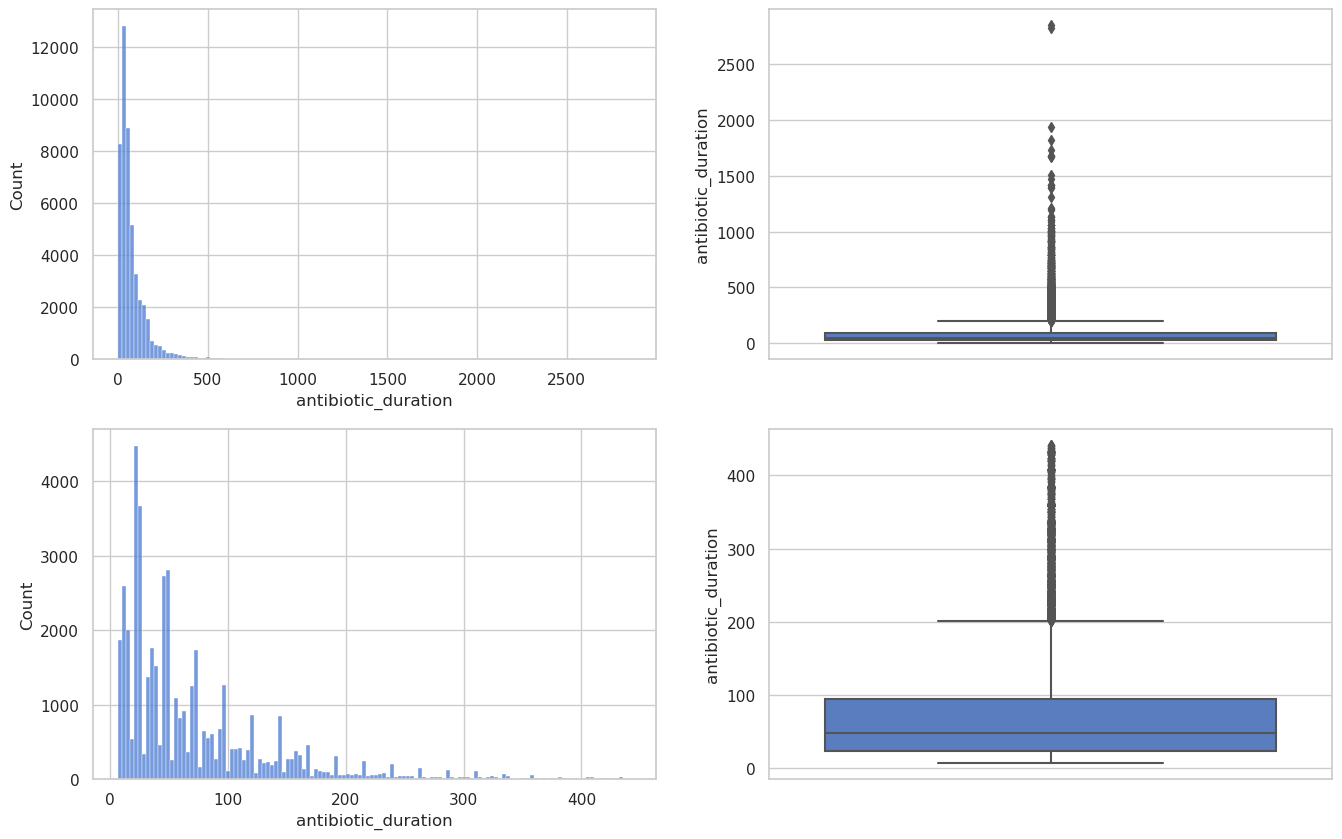

In [100]:
fig, axes = plt.subplots(2,2,figsize=(16,10))
sns.boxplot(
	data=df_antibiotics_durations.to_pandas(), y='antibiotic_duration', ax=axes[0][1]
)
sns.histplot(
	data=df_antibiotics_durations.to_pandas(), x='antibiotic_duration', bins=128, ax=axes[0][0]
)

sns.boxplot(
	data=df_antibiotics_durations_no_outliers.to_pandas(), y='antibiotic_duration', ax=axes[1][1]
)
sns.histplot(
	data=df_antibiotics_durations_no_outliers.to_pandas(), x='antibiotic_duration', bins=128, ax=axes[1][0]
)

### Blood culture analysis

In [31]:
os.listdir(Path(os.path.dirname(input_output_config_3.output_path)) / Path('phase3_v3'))

['df_sepsis3.parquet',
 'df_infect_long.parquet',
 'df_sepsis1.parquet',
 'df_all_layer1.parquet',
 'df_agg.parquet',
 'figures',
 'df_sepsis2.parquet',
 'df_all.parquet',
 'df_sirs_postagg.parquet',
 'df_septicshock.parquet',
 'experiment_config.json',
 'df_o2vent.parquet',
 'df_organdysfunction.parquet']

In [ ]:
df_sirs_postagg = pl.read_parquet(
	os.path.join(
		os.path.dirname(input_output_config_3.output_path),'phase3_v3','df_sirs_postagg.parquet'
	)
)


df_infect = pl.read_parquet(
	os.path.join(
		os.path.dirname(input_output_config_3.output_path),'phase3_v3','df_infect_long.parquet'
	)
)

In [149]:
rows = (
    df_sirs_postagg.sort(by=['EncounterEpicCsn', "Event_DateTime"])
    .with_columns(
        pl.when(
			pl.col("sirs_score")>=2
		).then(
			pl.lit(">=2")
		).otherwise(
			pl.lit("<2")
		).alias('sirs_group')
	)
    .with_columns(
        (pl.col("sirs_group") != pl.col("sirs_group").shift(1).over("EncounterEpicCsn"))
		.fill_null(True)
        .cum_sum()
		.over('EncounterEpicCsn')
		.alias("course_id")
	)
)
courses = (
    rows.group_by(['EncounterEpicCsn', 'course_id'])
	.agg(
		pl.col("sirs_group").first().alias("sirs_group"),
        pl.col("Event_DateTime").min().alias("start_dt"),
        pl.col("Event_DateTime").max().alias("end_dt"),
	).sort(by=['EncounterEpicCsn', 'course_id'])
	.with_columns(
        # pl.col("end_dt").shift(1).over("EncounterEpicCsn").alias("prev_end"),
        pl.col("start_dt").alias("prev_end"),
        pl.col("start_dt").shift(-1).over("EncounterEpicCsn").alias("next_start"),
	).with_columns(
		(pl.col("end_dt") - pl.col("start_dt"))
			.dt.total_hours(fractional=True).alias("internal_hours"),
		(pl.col("next_start") - pl.col("prev_end"))
			.dt.total_hours(fractional=True).alias("gap_hours"),
        )
    .sort(by=['EncounterEpicCsn', 'course_id'])
)

In [150]:
courses

EncounterEpicCsn,course_id,sirs_group,start_dt,end_dt,prev_end,next_start,internal_hours,gap_hours
i64,u32,str,datetime[μs],datetime[μs],datetime[μs],datetime[μs],f64,f64
659308243,1,"""<2""",2022-06-14 10:50:00,2022-06-14 22:05:00,2022-06-14 10:50:00,2022-06-14 22:10:00,11.25,11.333333
659308243,2,""">=2""",2022-06-14 22:10:00,2022-06-14 22:45:00,2022-06-14 22:10:00,2022-06-14 23:00:00,0.583333,0.833333
659308243,3,"""<2""",2022-06-14 23:00:00,2022-06-14 23:00:00,2022-06-14 23:00:00,2022-06-14 23:15:00,0.0,0.25
659308243,4,""">=2""",2022-06-14 23:15:00,2022-06-14 23:30:00,2022-06-14 23:15:00,2022-06-14 23:45:00,0.25,0.5
659308243,5,"""<2""",2022-06-14 23:45:00,2022-06-14 23:45:00,2022-06-14 23:45:00,2022-06-15 00:00:00,0.0,0.25
…,…,…,…,…,…,…,…,…
753665697,5,"""<2""",2026-05-27 15:42:35,2026-06-05 02:06:26.310,2026-05-27 15:42:35,null,202.397586,null
753676594,1,"""<2""",2026-05-26 17:49:00,2026-05-31 08:55:00,2026-05-26 17:49:00,null,111.1,null
753679492,1,"""<2""",2026-05-26 20:20:00,2026-05-30 07:32:00,2026-05-26 20:20:00,null,83.2,null


10.0 minutes
0.25 hours


(None, None)

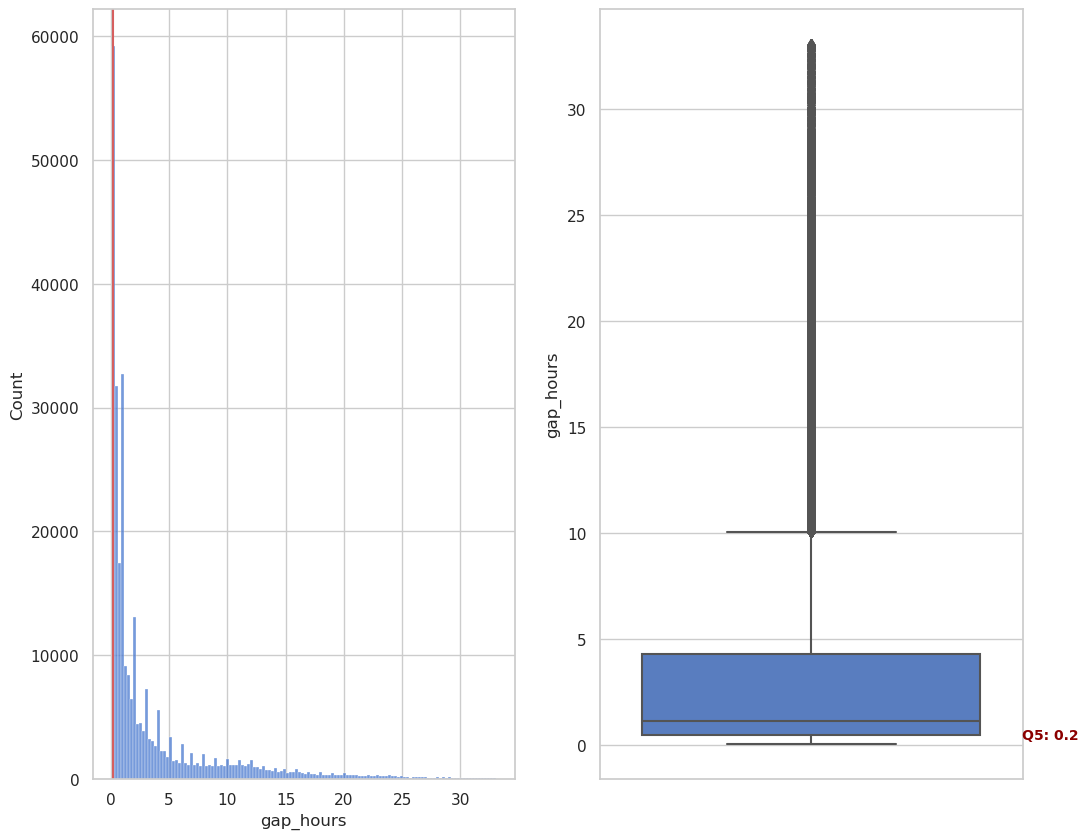

In [151]:
DURATION = 'gap_hours'  # use 'gap_hours' to match your current measure
courses_lt_2 = courses.filter(pl.col('sirs_group') == '<2')
courses_no_outliers_1percent_2tail = courses_lt_2.filter(
    (pl.col(DURATION) > pl.col(DURATION).quantile(0.05))&
	(pl.col(DURATION) < pl.col(DURATION).quantile(0.95))
)
fig, axes = plt.subplots(1,2,figsize=(12,10))
sns.boxplot(
    data=courses_no_outliers_1percent_2tail.to_pandas(), y=DURATION, ax=axes[1]
)

q5 = courses_no_outliers_1percent_2tail[DURATION].quantile(0.05)
axes[1].text(
	0.5, q5, f"Q5: {q5:.1f}", fontsize=10, color="darkred", fontweight="bold", va="bottom"
)
ax = sns.histplot(
    data=courses_no_outliers_1percent_2tail.to_pandas(), x=DURATION, ax=axes[0], bins=128
)

ax.axvline(x=q5, c='r')

print(courses_no_outliers_1percent_2tail[DURATION].quantile(0.05)*60, 'minutes'), print(courses_no_outliers_1percent_2tail[DURATION].quantile(0.15), 'hours')

In [152]:
DURATION_COL = "gap_hours"        # recommended; use "internal_hours" to match your current measure

courses = courses.with_columns(
    (
        (pl.col("sirs_group") == "<2")
        & pl.col("prev_end").is_not_null()      # interior on the left
        & pl.col("next_start").is_not_null()    # interior on the right
        & 
        ((pl.col(DURATION_COL) < 0.25)
		| (pl.col("internal_hours") < 0.25))
    ).alias("is_short_interruption")
)

In [153]:
courses

EncounterEpicCsn,course_id,sirs_group,start_dt,end_dt,prev_end,next_start,internal_hours,gap_hours,is_short_interruption
i64,u32,str,datetime[μs],datetime[μs],datetime[μs],datetime[μs],f64,f64,bool
659308243,1,"""<2""",2022-06-14 10:50:00,2022-06-14 22:05:00,2022-06-14 10:50:00,2022-06-14 22:10:00,11.25,11.333333,false
659308243,2,""">=2""",2022-06-14 22:10:00,2022-06-14 22:45:00,2022-06-14 22:10:00,2022-06-14 23:00:00,0.583333,0.833333,false
659308243,3,"""<2""",2022-06-14 23:00:00,2022-06-14 23:00:00,2022-06-14 23:00:00,2022-06-14 23:15:00,0.0,0.25,true
659308243,4,""">=2""",2022-06-14 23:15:00,2022-06-14 23:30:00,2022-06-14 23:15:00,2022-06-14 23:45:00,0.25,0.5,false
659308243,5,"""<2""",2022-06-14 23:45:00,2022-06-14 23:45:00,2022-06-14 23:45:00,2022-06-15 00:00:00,0.0,0.25,true
…,…,…,…,…,…,…,…,…,…
753665697,5,"""<2""",2026-05-27 15:42:35,2026-06-05 02:06:26.310,2026-05-27 15:42:35,null,202.397586,null,false
753676594,1,"""<2""",2026-05-26 17:49:00,2026-05-31 08:55:00,2026-05-26 17:49:00,null,111.1,null,false
753679492,1,"""<2""",2026-05-26 20:20:00,2026-05-30 07:32:00,2026-05-26 20:20:00,null,83.2,null,false


In [154]:
merged = (
    rows.join(
        courses.select("EncounterEpicCsn", "course_id", "is_short_interruption"),
        on=["EncounterEpicCsn", "course_id"], how="left",
    )
    .with_columns(
        pl.when(pl.col("is_short_interruption"))
          .then(pl.lit(">=2"))
          .otherwise(pl.col("sirs_group"))
          .alias("sirs_group_eff")
    )
    .with_columns(
        (pl.col("sirs_group_eff") != pl.col("sirs_group_eff").shift(1).over("EncounterEpicCsn"))
        .fill_null(True)
        .cum_sum()
        .over("EncounterEpicCsn")
        .alias("merged_course_id")        # <-- the re-encoded, gap-bridged courses
    )
)

df_sirs_courses_merged = (
    merged.group_by("EncounterEpicCsn", "merged_course_id")
          .agg(
              pl.col("sirs_group_eff").first().alias("sirs_group"),
              pl.col("Event_DateTime").min().alias("start_dt"),
              pl.col("Event_DateTime").max().alias("end_dt"),
          )
          .with_columns(
              (pl.col("end_dt") - pl.col("start_dt"))
                  .dt.total_hours(fractional=True).alias("duration")
          )
          .sort("EncounterEpicCsn", "merged_course_id")
)

In [155]:
df_sirs_courses_merged.filter(pl.col("EncounterEpicCsn")!=659308243).to_pandas().head(20)

,EncounterEpicCsn,merged_course_id,sirs_group,start_dt,end_dt,duration
0,660956097,1,<2,2022-06-27 11:01:00.000,2022-06-28 02:10:12.197,15.153388
1,660956097,2,>=2,2022-06-28 02:45:00.000,2022-06-29 05:00:00.000,26.250000
2,660956097,3,<2,2022-06-29 05:15:00.000,2022-06-29 11:00:00.000,5.750000
3,660956097,4,>=2,2022-06-29 12:00:00.000,2022-06-29 19:40:00.000,7.666667
4,660956097,5,<2,2022-06-29 20:00:00.000,2022-06-30 04:30:00.000,8.500000
5,660956097,6,>=2,2022-06-30 04:49:00.000,2022-06-30 09:56:00.000,5.116667
6,660956097,7,<2,2022-06-30 10:00:00.000,2022-06-30 14:00:00.000,4.000000
7,660956097,8,>=2,2022-06-30 15:00:00.000,2022-06-30 15:00:00.000,0.000000
8,660956097,9,<2,2022-06-30 15:23:00.000,2022-07-01 05:00:00.000,13.616667
9,660956097,10,>=2,2022-07-01 05:05:00.000,2022-07-01 05:05:00.000,0.000000


8.0 minutes
0.13333333333333333 hours
15.0 minutes
0.25 hours


(None, None)

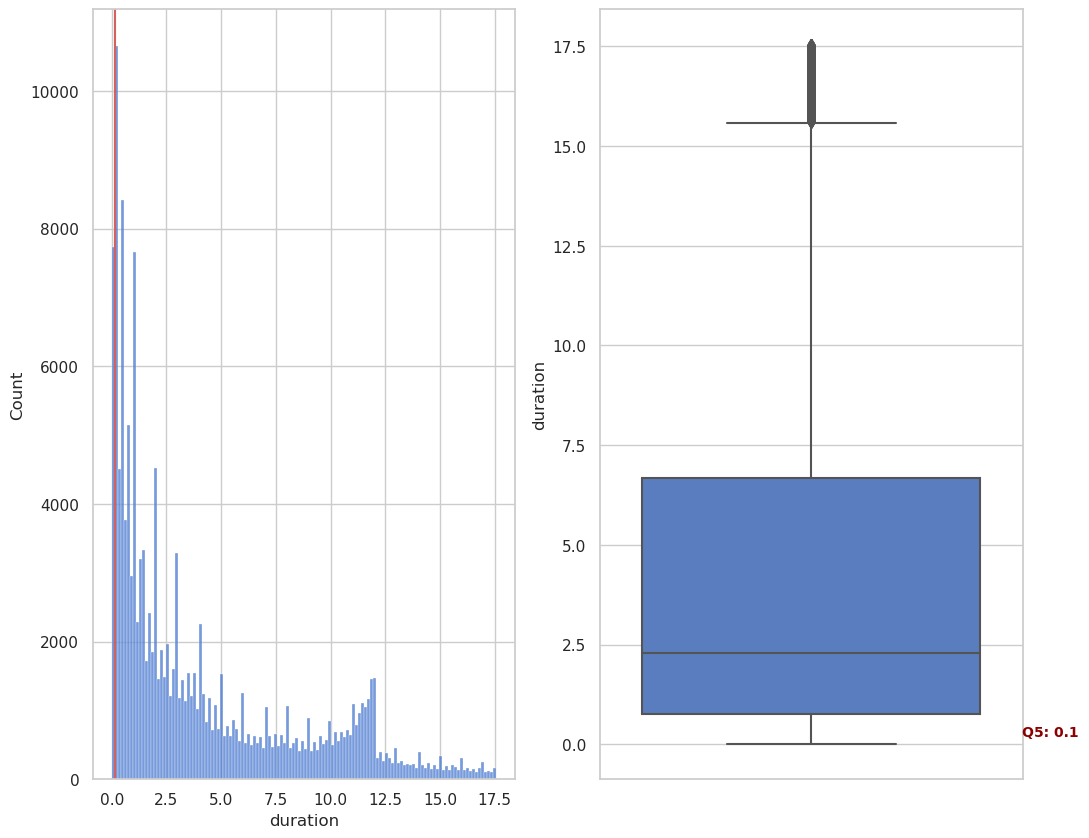

In [156]:
DURATION = 'duration'  # use 'gap_hours' to match your current measure
courses_lt_2 = df_sirs_courses_merged.filter(pl.col('sirs_group') == '>=2')
courses_no_outliers_1percent_2tail = courses_lt_2.filter(
    (pl.col(DURATION) > pl.col(DURATION).quantile(0.05))&
	(pl.col(DURATION) < pl.col(DURATION).quantile(0.95))
)
fig, axes = plt.subplots(1,2,figsize=(12,10))
sns.boxplot(
    data=courses_no_outliers_1percent_2tail.to_pandas(), y=DURATION, ax=axes[1]
)

q5 = courses_no_outliers_1percent_2tail[DURATION].quantile(0.05)
axes[1].text(
	0.5, q5, f"Q5: {q5:.1f}", fontsize=10, color="darkred", fontweight="bold", va="bottom"
)
ax = sns.histplot(
    data=courses_no_outliers_1percent_2tail.to_pandas(), x=DURATION, ax=axes[0], bins=128
)

ax.axvline(x=q5, c='r')

print(courses_no_outliers_1percent_2tail[DURATION].quantile(0.05)*60, 'minutes'), print(courses_no_outliers_1percent_2tail[DURATION].quantile(0.05), 'hours')
print(courses_no_outliers_1percent_2tail[DURATION].quantile(0.1)*60, 'minutes'), print(courses_no_outliers_1percent_2tail[DURATION].quantile(0.1), 'hours')

In [148]:
0.06666667*60

4.0000002

In [ ]:
DURATION_COL = ""
df_sirs_courses_durations.filter(
    (pl.col(DURATION_COL) > pl.col(DURATION_COL).quantile(0.05))&
	(pl.col(DURATION_COL) < pl.col(DURATION_COL).quantile(0.95))
).describe()

statistic,EncounterEpicCsn,course_id,sirs_group,start_dt,end_dt,prev_end,next_start,internal_hours,gap_hours
str,f64,f64,str,str,str,str,str,f64,f64
"""count""",429479.0,429479.0,"""429479""","""429479""","""429479""","""417724""","""429463""",429479.0,417708.0
"""null_count""",0.0,0.0,"""0""","""0""","""0""","""11755""","""16""",0.0,11771.0
"""mean""",7.0668e8,143.616209,null,"""2024-07-04 04:35:56.179064""","""2024-07-04 08:36:50.485445""","""2024-07-04 16:05:48.399567""","""2024-07-04 09:25:28.233632""",4.015085,5.382306
"""std""",2.5103e7,311.831815,null,null,null,null,null,5.639015,6.977578
"""min""",6.59308243e8,1.0,"""<2""","""2022-06-01 00:51:00""","""2022-06-01 05:35:00""","""2022-06-01 06:00:00""","""2022-06-01 06:00:00""",0.000278,0.018333
"""25%""",6.84902042e8,15.0,null,"""2023-08-01 12:15:00""","""2023-08-01 16:22:00""","""2023-08-02 13:00:00""","""2023-08-01 17:18:00""",0.45,1.083333
"""50%""",7.05174047e8,50.0,null,"""2024-07-12 09:30:00""","""2024-07-12 13:05:00""","""2024-07-12 17:09:00""","""2024-07-12 13:45:00""",1.5,2.75
"""75%""",7.27928303e8,144.0,null,"""2025-06-16 11:00:00""","""2025-06-16 14:00:00""","""2025-06-16 14:15:00""","""2025-06-16 15:00:00""",5.216667,7.083333
"""max""",7.53665697e8,4448.0,""">=2""","""2026-05-31 10:21:00""","""2026-05-31 15:00:00""","""2026-05-31 09:36:00""","""2026-06-03 02:19:37.180000""",33.492731,374.165261


0.16666666666666666

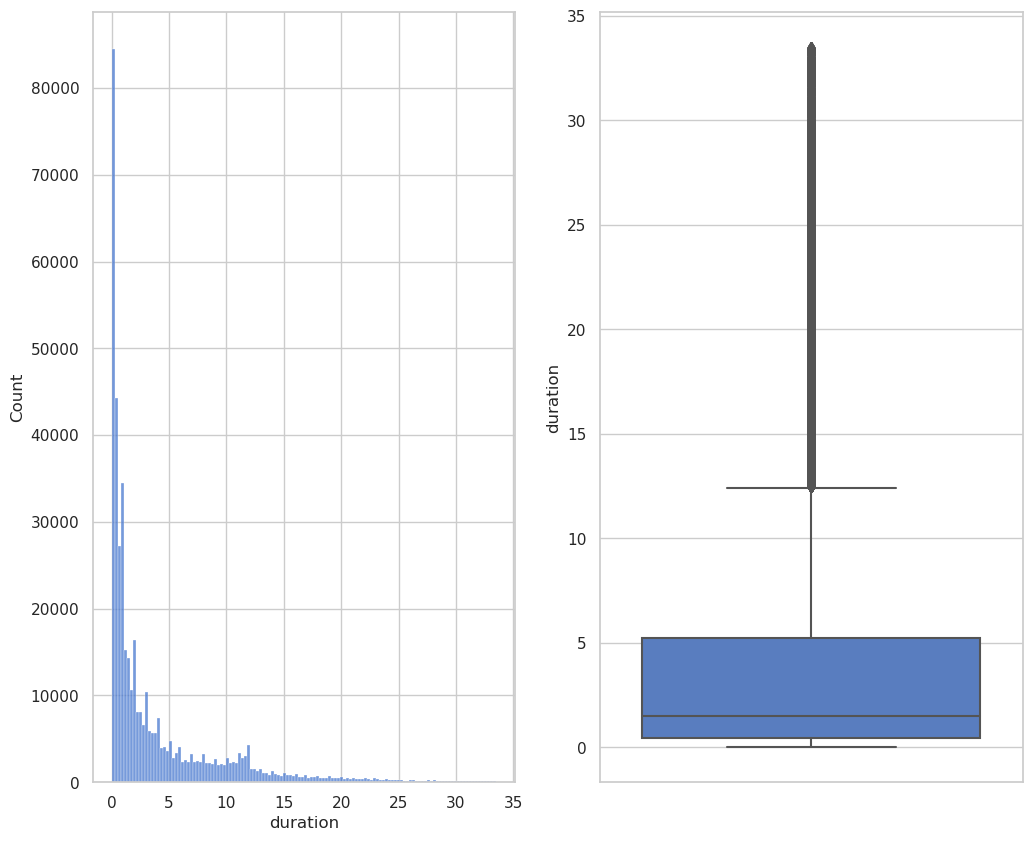

In [31]:
df_antibiotics_durations.group_by("Event_Name").agg(
    pl.col("antibiotic_duration").sort(),
	pl.col("antibiotic_duration").quantile(0.25).alias("Q25"),
	pl.col("antibiotic_duration").quantile(0.5).alias("median"),
	pl.col("antibiotic_duration").quantile(0.75).alias("Q75"),
    pl.len()
).sort(by='median', descending=True).to_pandas().head(30)

,Event_Name,antibiotic_duration,Q25,median,Q75,len
0,SULFAMETHOXAZOLE-TRIMETHOPRIM IVPB 100 ML,"[72.14999999999999, 429.20416666666665, 599.98...",429.204167,599.988889,599.988889,4
1,CEFAZOLIN 2 GM COMPOUND IVPB,"[31.2, 520.0]",31.200000,520.000000,520.000000,2
2,IMIPENEM-CILASTATIN 250 MG IVPB,[497.18583333333333],497.185833,497.185833,497.185833,1
3,IMIPENEM-CILASTATIN CUSTOM DOSE IVPB,[456.59444444444443],456.594444,456.594444,456.594444,1
4,CEFTAZIDIME IN NS 500 ML CONTINUOUS INFUSION,"[22.75583333333333, 448.52777777777777]",22.755833,448.527778,448.527778,2
5,MICAFUNGIN 300 MG IVPB,"[68.83, 244.80249999999998, 314.7, 962.3919444...",244.802500,314.700000,314.700000,4
6,COLISTIMETHATE IVPB,"[134.0686111111111, 230.79749999999999, 256.32...",256.321944,287.108333,329.706944,10
7,IMIPENEM-CILASTATIN 1 GM IVPB,"[6.317222222222222, 22.480833333333333, 32.949...",118.520278,271.665000,479.566111,34
8,MICAFUNGIN 100 MG IVPB (VIAL2BAG),"[47.241388888888885, 47.33555555555555, 253.48...",47.335556,253.481944,253.481944,4
9,TOBRAMYCIN CUSTOM DOSE IVPB IN NS,"[96.57944444444443, 97.53777777777778, 218.303...",97.537778,218.303056,218.303056,4


<Axes: xlabel='Event_Name', ylabel='antibiotic_duration'>

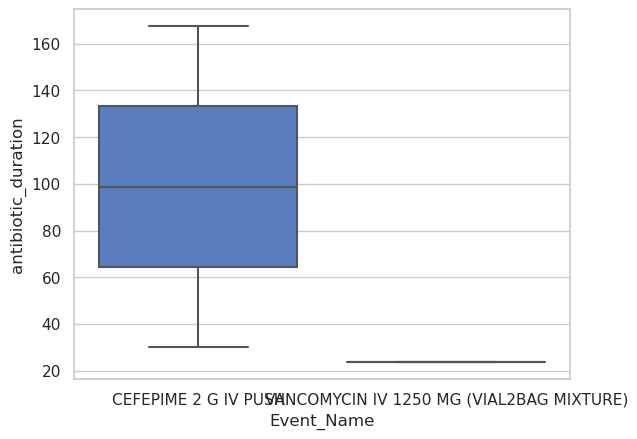

In [ ]:
sns.boxplot(
    data=df_antibiotics_durations.sort().to_pandas().head(3),
	y='antibiotic_duration',
	x='Event_Name',
)

In [101]:
df_antibiotics_durations_no_outliers['antibiotic_duration'].describe()

statistic,value
str,f64
"""count""",46965.0
"""null_count""",0.0
"""mean""",70.278916
"""std""",66.666797
"""min""",6.9
"""25%""",23.966667
"""50%""",47.737222
"""75%""",94.783333
"""max""",441.690556


In [103]:
df_antibiotics_durations_no_outliers.join(
	df_enc,
	on='EncounterEpicCsn',
	how='inner'
).filter(
    pl.col("antibiotic_duration") >= 48 
)['Sepsis_Category'].value_counts(sort=True)

Sepsis_Category,count
str,u64
"""POA-1""",7382
"""POA-3""",6195
"""NPOA-3""",3809
"""POA-2""",3179
"""NPOA-1""",1820
"""NPOA-2""",461
"""UPOA-1""",46
"""UPOA-3""",17
"""UPOA-2""",13


In [109]:
df_antibiotics_durations_no_outliers.join(
	df_enc,
	on='EncounterEpicCsn',
	how='inner'
).with_columns(
    pl.when(pl.col("antibiotic_duration") >= 48).then(pl.lit(">=48hrs")).otherwise(pl.lit("<48hrs")).alias("antibiotic_duration_groups")
).group_by("EncounterEpicCsn", "antibiotic_duration_groups").agg(
    pl.col("Sepsis_Category").first(),
    pl.len()
).sort(by=["EncounterEpicCsn", "antibiotic_duration_groups"])

EncounterEpicCsn,antibiotic_duration_groups,Sepsis_Category,len
i64,str,str,u64
659308243,"""<48hrs""","""NPOA-3""",5
659308243,""">=48hrs""","""NPOA-3""",2
661424247,"""<48hrs""","""NPOA-3""",2
661424247,""">=48hrs""","""NPOA-3""",1
662152913,"""<48hrs""","""POA-2""",3
…,…,…,…
753558469,"""<48hrs""","""POA-3""",4
753563196,"""<48hrs""","""POA-2""",2
753573877,""">=48hrs""","""POA-1""",1
